**IMPORT NEEDED PACKAGE**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, precision_recall_curve, auc
)
from sklearn.ensemble import RandomForestClassifier

In [3]:
try:
    from imblearn.over_sampling import SMOTE
except:
    import sys
    !{sys.executable} -m pip install imbalanced-learn
    from imblearn.over_sampling import SMOTE

sns.set(style="whitegrid")
RANDOM_STATE = 42

**LOAD DATA**

In [4]:
df = pd.read_csv('data-bank.csv')
df.head()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [5]:
df.columns = df.columns.str.strip()

In [6]:
print("=== INFORMASI DATASET ===")
print("Jumlah Baris & Kolom:", df.shape)

=== INFORMASI DATASET ===
Jumlah Baris & Kolom: (6819, 96)


In [7]:
print("\nInfo dataset:")
print(df.info())


Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   Bankrupt?                                                6819 non-null   int64  
 1   ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2   ROA(A) before interest and % after tax                   6819 non-null   float64
 3   ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4   Operating Gross Margin                                   6819 non-null   float64
 5   Realized Sales Gross Margin                              6819 non-null   float64
 6   Operating Profit Rate                                    6819 non-null   float64
 7   Pre-tax net Interest Rate                                6819 non-null   float64
 8   After-tax net

**TARGET DISTRUBUSI**

In [8]:
if 'Bankrupt?' not in df.columns:
    raise ValueError("Kolom 'Bankrupt?' tidak ditemukan.")
print("\nDistribusi target:")
print(df['Bankrupt?'].value_counts())
print("\n% each class:")
print(df['Bankrupt?'].value_counts(normalize=True) * 100)


Distribusi target:
Bankrupt?
0    6599
1     220
Name: count, dtype: int64

% each class:
Bankrupt?
0    96.77372
1     3.22628
Name: proportion, dtype: float64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12852\1077414681.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Bankrupt?', data=df, palette=['#2ca02c','#d62728'])


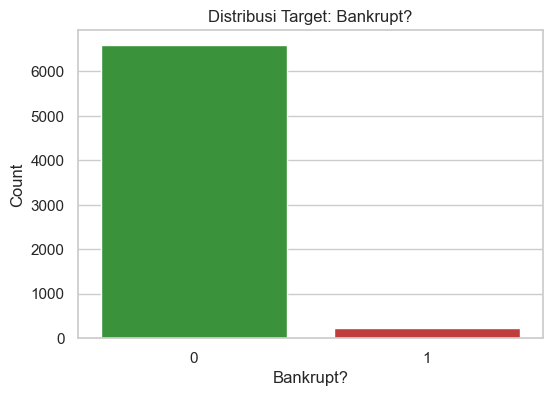

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Bankrupt?', data=df, palette=['#2ca02c','#d62728'])
plt.title('Distribusi Target: Bankrupt?')
plt.xlabel('Bankrupt?')
plt.ylabel('Count')
plt.show()

**EDA**

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns count:", len(numeric_cols))
display(df[numeric_cols].describe().T)


Numeric columns count: 96


,count,mean,std,min,25%,50%,75%,max
Bankrupt?,6819.0,0.032263,0.176710,0.0,0.000000,0.000000,0.000000,1.0
ROA(C) before interest and depreciation before interest,6819.0,0.505180,0.060686,0.0,0.476527,0.502706,0.535563,1.0
ROA(A) before interest and % after tax,6819.0,0.558625,0.065620,0.0,0.535543,0.559802,0.589157,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.553589,0.061595,0.0,0.527277,0.552278,0.584105,1.0
Operating Gross Margin,6819.0,0.607948,0.016934,0.0,0.600445,0.605997,0.613914,1.0
...,...,...,...,...,...,...,...,...
Liability to Equity,6819.0,0.280365,0.014463,0.0,0.276944,0.278778,0.281449,1.0
Degree of Financial Leverage (DFL),6819.0,0.027541,0.015668,0.0,0.026791,0.026808,0.026913,1.0
Interest Coverage Ratio (Interest expense to EBIT),6819.0,0.565358,0.013214,0.0,0.565158,0.565252,0.565725,1.0
Net Income Flag,6819.0,1.000000,0.000000,1.0,1.000000,1.000000,1.000000,1.0


In [11]:
missing = df.isnull().mean().sort_values(ascending=False)
print("\nMissing value percent (if any):")
display(missing[missing > 0])


Missing value percent (if any):


Series([], dtype: float64)

In [12]:
num_imputer = SimpleImputer(strategy='median')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

**KORELASI HEATMAP**

In [13]:
plt.figure(figsize=(12,10))
corr = df[numeric_cols].corr()

<Figure size 1200x1000 with 0 Axes>

In [14]:
corr_target = corr['Bankrupt?'].abs().sort_values(ascending=False)
top10 = corr_target.index[1:11]  # ambil 10 fitur teratas selain target

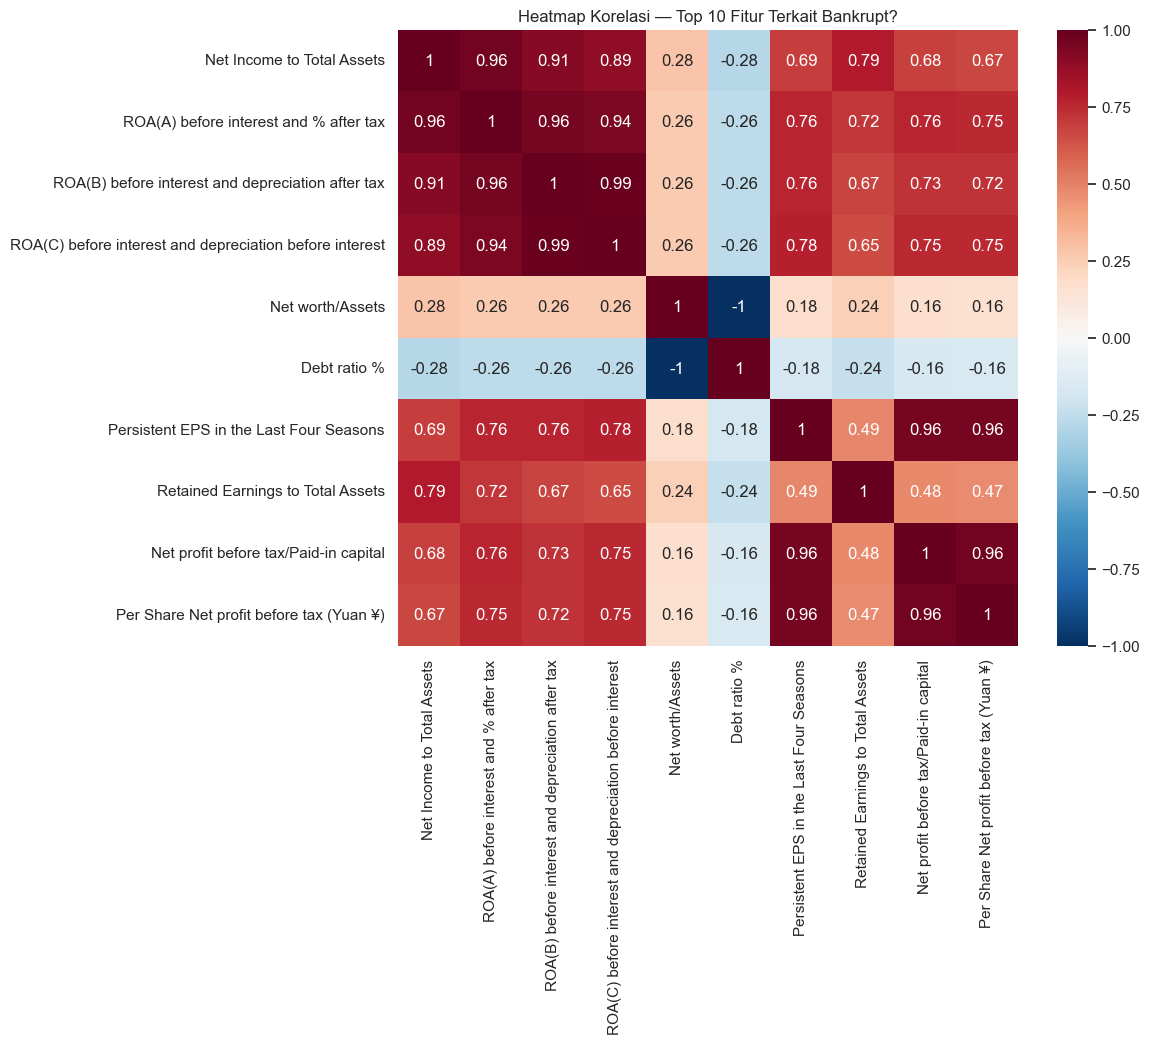

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df[top10].corr(), annot=True, cmap='RdBu_r', center=0)
plt.title("Heatmap Korelasi — Top 10 Fitur Terkait Bankrupt?")
plt.show()

In [16]:
print("\n=== Top 10 Fitur Korelasi Tertinggi ke Bankrupt? ===")
display(corr_target.head(11))


=== Top 10 Fitur Korelasi Tertinggi ke Bankrupt? ===


Bankrupt?                                                  1.000000
Net Income to Total Assets                                 0.315457
ROA(A) before interest and % after tax                     0.282941
ROA(B) before interest and depreciation after tax          0.273051
ROA(C) before interest and depreciation before interest    0.260807
Net worth/Assets                                           0.250161
Debt ratio %                                               0.250161
Persistent EPS in the Last Four Seasons                    0.219560
Retained Earnings to Total Assets                          0.217779
Net profit before tax/Paid-in capital                      0.207857
Per Share Net profit before tax (Yuan ¥)                   0.201395
Name: Bankrupt?, dtype: float64

In [17]:
top_features = corr_target.index[1:6]   # ambil 5 fitur teratas
print("\nFitur terpilih untuk visualisasi 2 variabel:", top_features.tolist())


Fitur terpilih untuk visualisasi 2 variabel: ['Net Income to Total Assets', 'ROA(A) before interest and % after tax', 'ROA(B) before interest and depreciation after tax', 'ROA(C) before interest and depreciation before interest', 'Net worth/Assets']


**VISUALISASI HUBUNGAN 2 VAR**

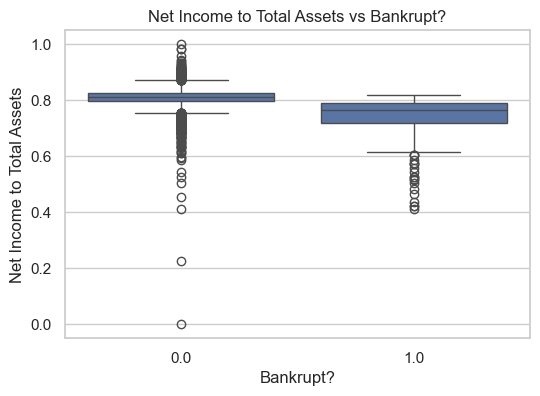

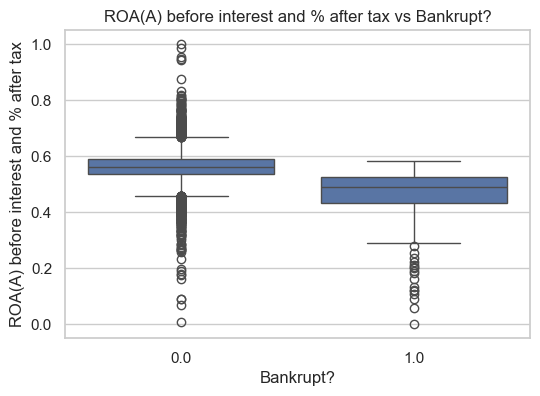

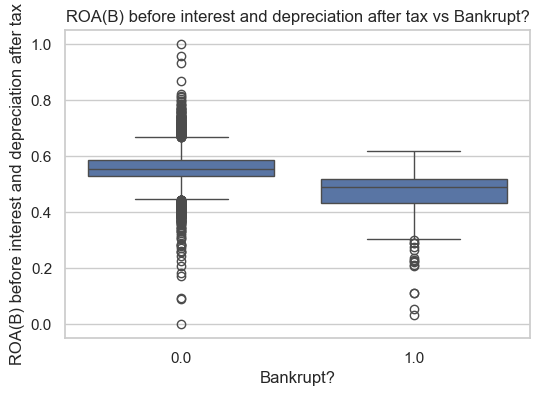

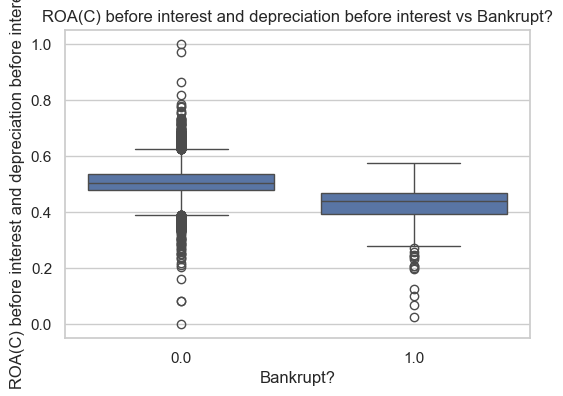

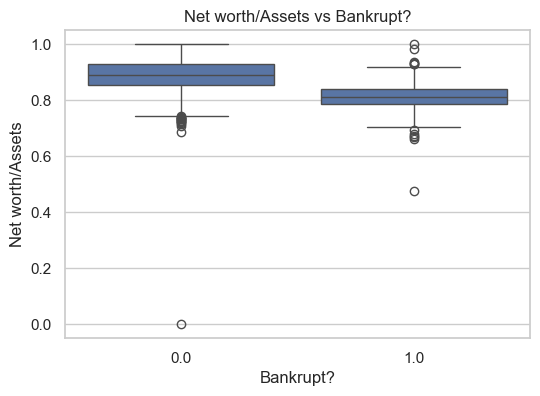

In [18]:
for col in top_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Bankrupt?', y=col, data=df)
    plt.title(f"{col} vs Bankrupt?")
    plt.show()

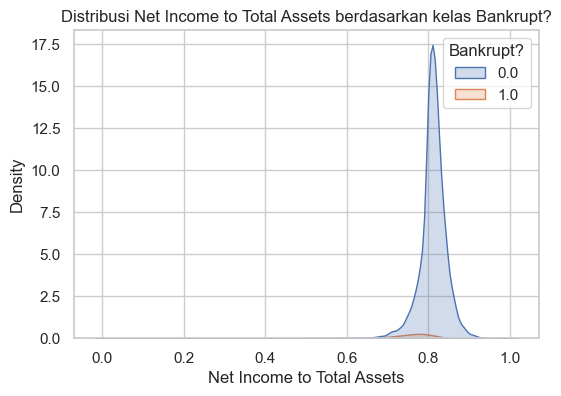

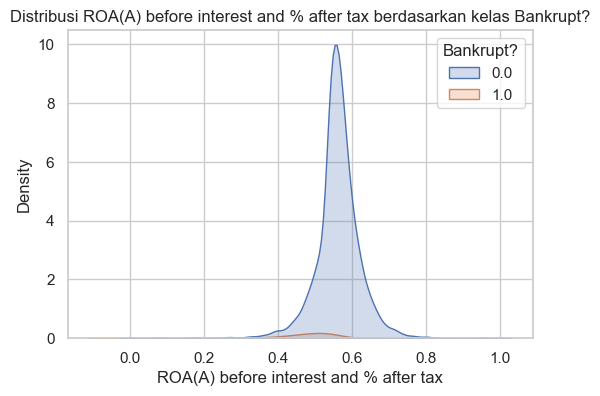

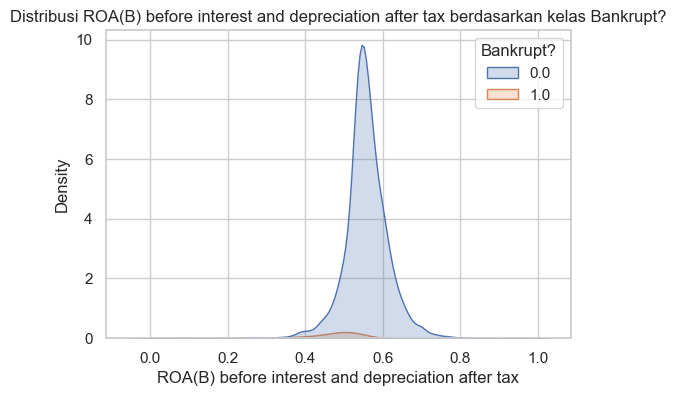

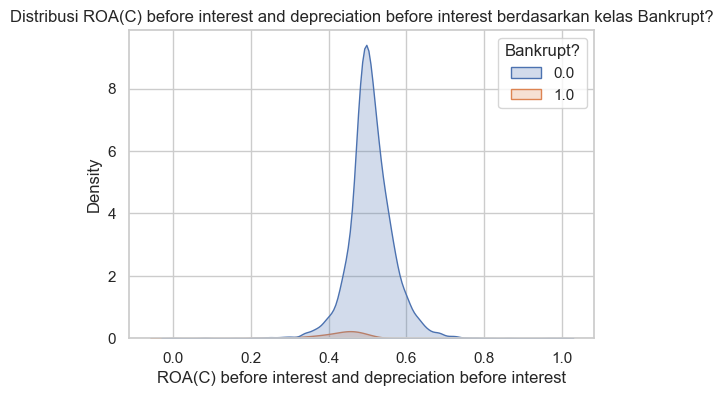

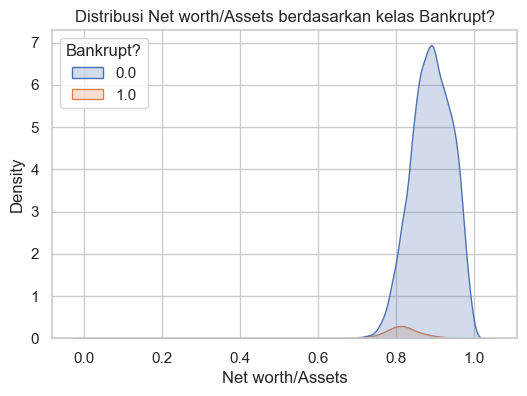

In [19]:
for col in top_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue='Bankrupt?', fill=True)
    plt.title(f"Distribusi {col} berdasarkan kelas Bankrupt?")
    plt.show()

**SPLIT DATABASE**

In [20]:
X = df.drop('Bankrupt?', axis=1)
X = X.select_dtypes(include=[np.number])  # gunakan numeric saja
y = df['Bankrupt?']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

In [22]:
print("\n=== Setelah Train-Test Split ===")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Train class:", Counter(y_train))


=== Setelah Train-Test Split ===
X_train: (5455, 95)
X_test : (1364, 95)
Train class: Counter({0.0: 5279, 1.0: 176})


**SCALING**

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

**BALANCING SMOTE**

In [24]:
print("\nJumlah sebelum SMOTE:", Counter(y_train))

sm = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

print("Jumlah setelah SMOTE:", Counter(y_res))


Jumlah sebelum SMOTE: Counter({0.0: 5279, 1.0: 176})
Jumlah setelah SMOTE: Counter({0.0: 5279, 1.0: 5279})


C:\Users\ASUS\AppData\Local\Temp\ipykernel_12852\2671790808.py:4: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  plt.bar(['Sehat','Bangkrut'], np.bincount(y_train))
C:\Users\ASUS\AppData\Local\Temp\ipykernel_12852\2671790808.py:8: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  plt.bar(['Sehat','Bangkrut'], np.bincount(y_res))


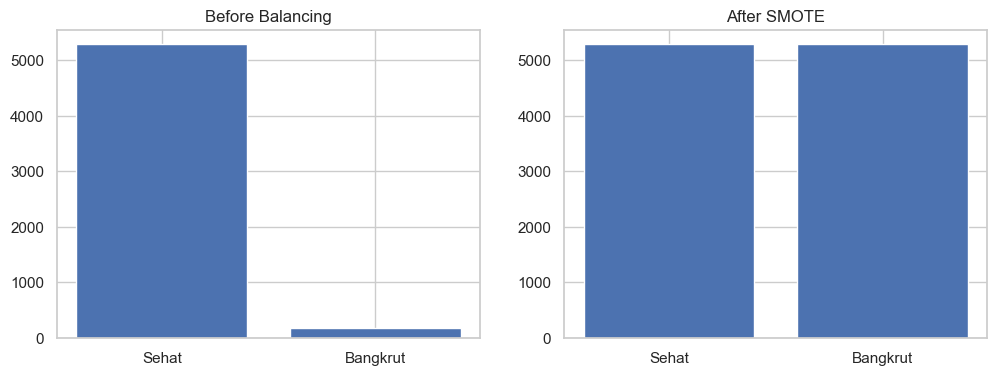

In [25]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.bar(['Sehat','Bangkrut'], np.bincount(y_train))
plt.title("Before Balancing")

plt.subplot(1,2,2)
plt.bar(['Sehat','Bangkrut'], np.bincount(y_res))
plt.title("After SMOTE")

plt.show()

**RANDOM FOREST TRAINING**

In [26]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

In [27]:
rf.fit(X_res, y_res)
y_pred = rf.predict(X_test_scaled)
y_prob = rf.predict_proba(X_test_scaled)[:,1]

**EVALUASI MODEL**

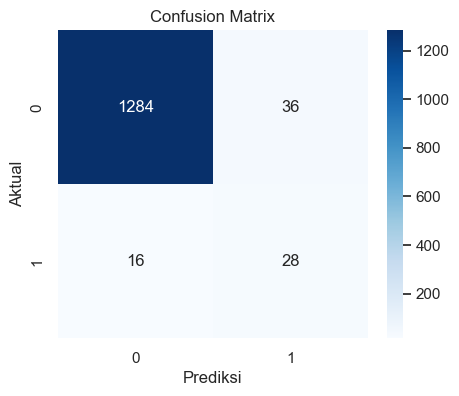

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

In [29]:
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))


=== Classification Report ===
              precision    recall  f1-score   support

         0.0     0.9877    0.9727    0.9802      1320
         1.0     0.4375    0.6364    0.5185        44

    accuracy                         0.9619      1364
   macro avg     0.7126    0.8045    0.7493      1364
weighted avg     0.9699    0.9619    0.9653      1364



In [30]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9454373278236915


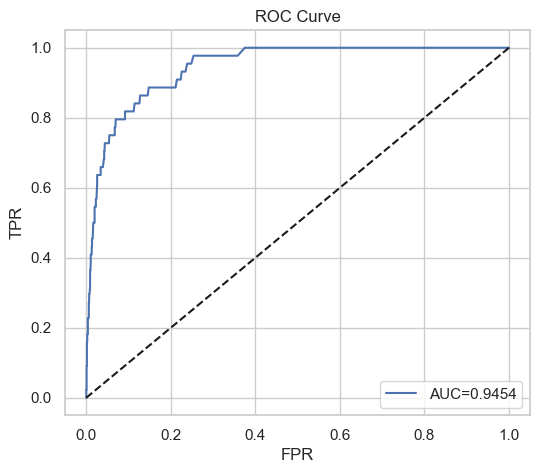

In [31]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC={roc_auc:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.show()

In [32]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

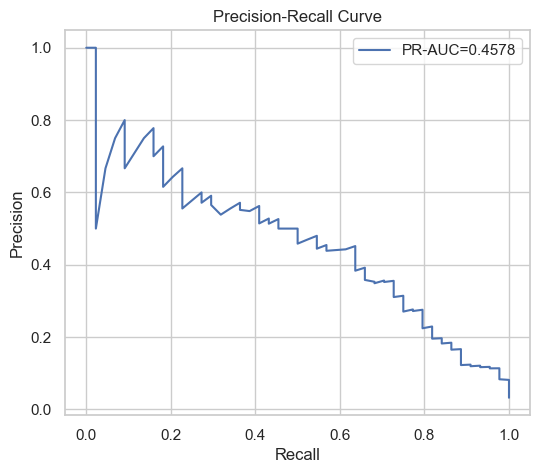

In [33]:
plt.figure(figsize=(6,5))
plt.plot(recall, precision, label=f"PR-AUC={pr_auc:.4f}")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [34]:
print("PR-AUC:", pr_auc)

PR-AUC: 0.4578470999494095


**FEATURE IMPORTANCE**

In [35]:
feat_imp = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

In [36]:
print("\n=== Top 5 Fitur Paling Penting (Random Forest) ===")
display(feat_imp.head(5))


=== Top 5 Fitur Paling Penting (Random Forest) ===


,feature,importance
39,Borrowing dependency,0.070829
9,Continuous interest rate (after tax),0.043324
18,Persistent EPS in the Last Four Seasons,0.042991
85,Net Income to Total Assets,0.041915
7,After-tax net Interest Rate,0.039021


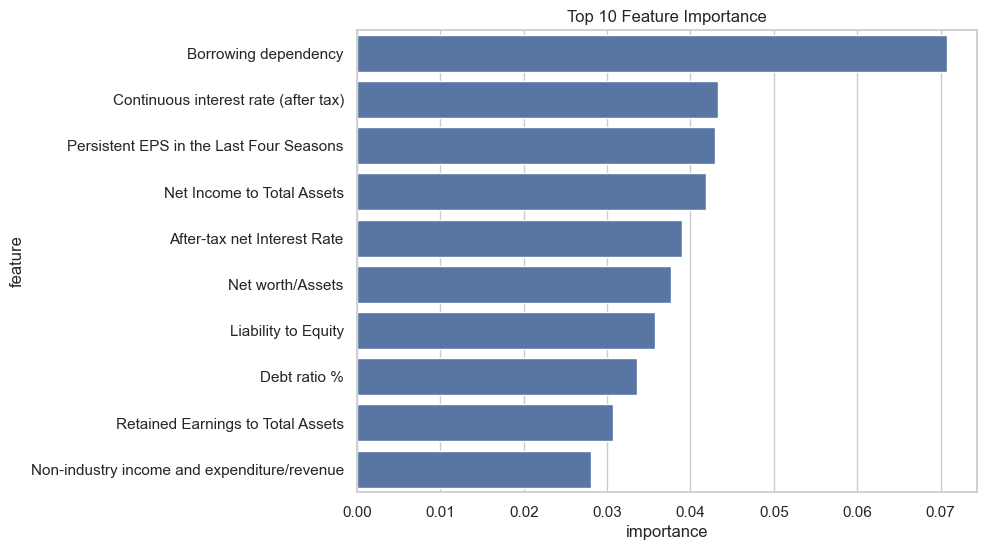

In [37]:
plt.figure(figsize=(8,6))
sns.barplot(x='importance', y='feature', data=feat_imp.head(10))
plt.title("Top 10 Feature Importance")
plt.show()